In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
#Environment Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
df = pd.read_csv('/content/drive/MyDrive/Data set/Telco customer churn.csv')
df.head(5)

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [72]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [73]:
print(df.shape)

(7043, 50)


In [74]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Offer             3877
Internet Type     1526
Churn Category    5174
Churn Reason      5174
dtype: int64


In [75]:
df['Offer'] = df['Offer'].fillna('None')
df['Internet Type'] = df['Internet Type'].fillna('None')
df = df.drop(columns=['Churn Category', 'Churn Reason'])
print(df.isnull().sum().sum())

0


In [76]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [77]:
# Numeric-looking columns jo galti se object ban jayein unko fix karna
numeric_check_cols = ['Total Charges', 'Total Refunds', 'Total Long Distance Charges', 'Total Revenue']
for col in numeric_check_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(df.isnull().sum().sum())  # agar 0 se zyada, matlab hidden blanks thi

0


In [83]:
# Ye columns model ko "answer" already de dete hain — cheating hoga
leakage_cols = ['Churn Score', 'CLTV', 'Satisfaction Score']
df = df.drop(columns=leakage_cols, errors='ignore')

# Ye columns useless hain (ID/location specific, model ke liye value nahi)
useless_cols = ['Customer ID', 'Country', 'State', 'City', 'Zip Code',
                 'Latitude', 'Longitude', 'Quarter', 'Customer Status']
df = df.drop(columns=useless_cols, errors='ignore')
print(df.shape)

(7043, 36)


In [104]:
df_original = df.copy()

In [84]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Total categorical columns: {len(categorical_cols)}\n")

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique → {df[col].unique()}")

Total categorical columns: 23

Gender: 2 unique → ['Male' 'Female']
Under 30: 2 unique → ['No' 'Yes']
Senior Citizen: 2 unique → ['Yes' 'No']
Married: 2 unique → ['No' 'Yes']
Dependents: 2 unique → ['No' 'Yes']
Referred a Friend: 2 unique → ['No' 'Yes']
Offer: 6 unique → ['None' 'Offer E' 'Offer D' 'Offer C' 'Offer B' 'Offer A']
Phone Service: 2 unique → ['No' 'Yes']
Multiple Lines: 2 unique → ['No' 'Yes']
Internet Service: 2 unique → ['Yes' 'No']
Internet Type: 4 unique → ['DSL' 'Fiber Optic' 'Cable' 'None']
Online Security: 2 unique → ['No' 'Yes']
Online Backup: 2 unique → ['No' 'Yes']
Device Protection Plan: 2 unique → ['Yes' 'No']
Premium Tech Support: 2 unique → ['No' 'Yes']
Streaming TV: 2 unique → ['No' 'Yes']
Streaming Movies: 2 unique → ['Yes' 'No']
Streaming Music: 2 unique → ['No' 'Yes']
Unlimited Data: 2 unique → ['No' 'Yes']
Contract: 3 unique → ['Month-to-Month' 'One Year' 'Two Year']
Paperless Billing: 2 unique → ['Yes' 'No']
Payment Method: 3 unique → ['Bank Withdrawal'

In [85]:
# 1️⃣ Gender ko alag map karo (Male/Female hai, Yes/No nahi)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# 2️⃣ Baaki saare Yes/No binary columns
binary_cols = ['Under 30', 'Senior Citizen', 'Married', 'Dependents',
               'Referred a Friend', 'Phone Service', 'Multiple Lines',
               'Internet Service', 'Online Security', 'Online Backup',
               'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
               'Streaming Movies', 'Streaming Music', 'Unlimited Data',
               'Paperless Billing', 'Churn Label']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 3️⃣ Multi-class columns → One-Hot Encoding
multi_class_cols = ['Offer', 'Internet Type', 'Contract', 'Payment Method']
df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)

# 4️⃣ Verify — ab koi object dtype nahi bachna chahiye
print(df.dtypes.value_counts())
print(df.select_dtypes(include='object').columns.tolist())   # empty list aani chahiye

# 5️⃣ NaN check (map fail hone par NaN aa sakta hai agar spelling mismatch ho)
print(df.isnull().sum().sum())   # 0 hona chahiye

int64      26
bool       12
float64     6
Name: count, dtype: int64
[]
0


In [86]:
df.isnull().sum()

,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Population,0
Referred a Friend,0
Number of Referrals,0


In [87]:
df.dtypes.value_counts()

,count
int64,26
bool,12
float64,6


In [88]:
# Bool columns ko explicitly int mein convert kar do (safe practice)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Final check
print(df.dtypes.value_counts())
print(df.isnull().sum().sum())   # 0 hona chahiye
df.shape

int64      38
float64     6
Name: count, dtype: int64
0


(7043, 44)

In [89]:
df.dtypes.value_counts()

,count
int64,38
float64,6


In [90]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn Label', axis=1)
y = df['Churn Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test: {y_test.mean():.2%}")

Train shape: (5634, 43)
Test shape: (1409, 43)
Churn rate in train: 26.54%
Churn rate in test: 26.54%


In [101]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb

# ---- Random Forest ----
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)   # scaling ki zaroorat nahi tree models mein
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print(classification_report(y_test, rf_pred))

# ---- XGBoost ----
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(classification_report(y_test, xgb_pred))

=== Random Forest ===
Accuracy: 0.8304
ROC-AUC: 0.9011
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1035
           1       0.65      0.79      0.71       374

    accuracy                           0.83      1409
   macro avg       0.78      0.82      0.80      1409
weighted avg       0.85      0.83      0.84      1409


=== XGBoost ===
Accuracy: 0.8531
ROC-AUC: 0.9098
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1035
           1       0.75      0.67      0.71       374

    accuracy                           0.85      1409
   macro avg       0.82      0.79      0.80      1409
weighted avg       0.85      0.85      0.85      1409



In [95]:
print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

print("\n=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

=== Random Forest ===
Accuracy: 0.8304
ROC-AUC: 0.9011

=== XGBoost ===
Accuracy: 0.8531
ROC-AUC: 0.9098


In [99]:
importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importance.head(10))

Contract_Two Year             0.240778
Contract_One Year             0.135295
Internet Service              0.118090
Internet Type_Fiber Optic     0.060681
Payment Method_Credit Card    0.044197
Number of Referrals           0.039306
Referred a Friend             0.037404
Streaming Movies              0.030169
Dependents                    0.030120
Paperless Billing             0.021736
dtype: float32


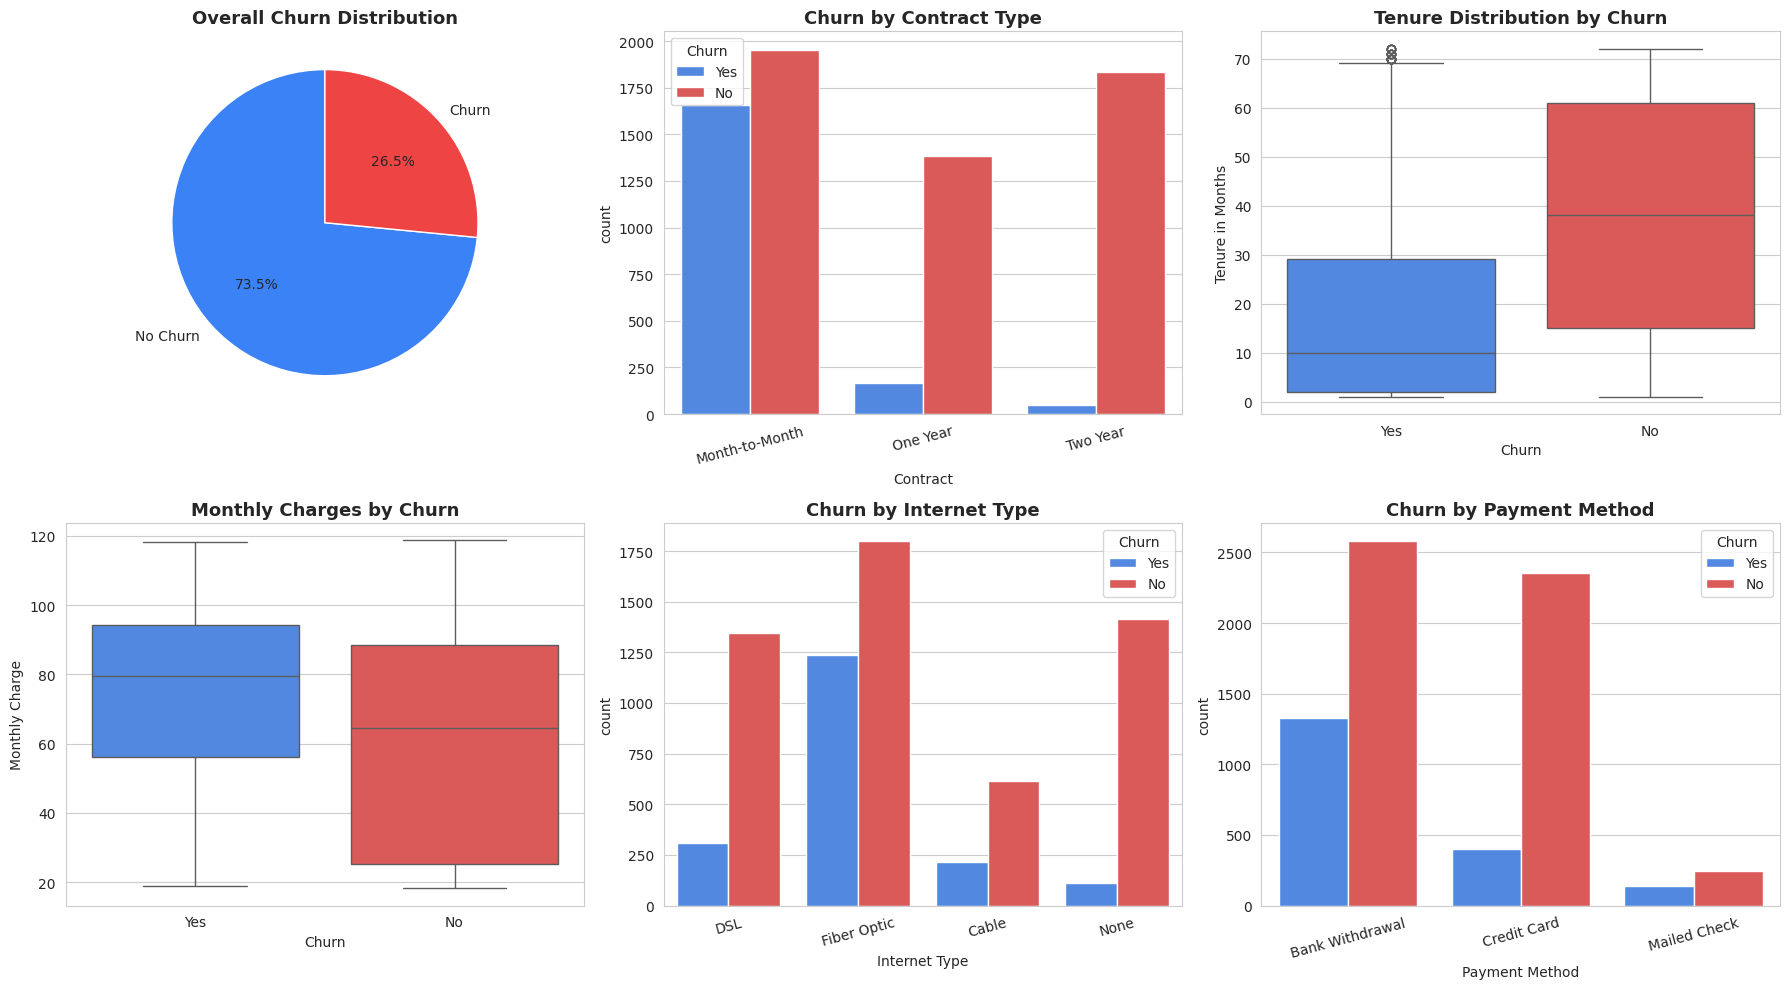

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Recreate a cleaned but untransformed DataFrame for plotting purposes
df_plots = pd.read_csv('/content/drive/MyDrive/Data set/Telco customer churn.csv')

# Apply cleaning steps that were done before one-hot encoding
df_plots['Offer'] = df_plots['Offer'].fillna('None')
df_plots['Internet Type'] = df_plots['Internet Type'].fillna('None')
df_plots = df_plots.drop(columns=['Churn Category', 'Churn Reason'], errors='ignore')

numeric_check_cols = ['Total Charges', 'Total Refunds', 'Total Long Distance Charges', 'Total Revenue']
for col in numeric_check_cols:
    df_plots[col] = pd.to_numeric(df_plots[col], errors='coerce')

leakage_cols = ['Churn Score', 'CLTV', 'Satisfaction Score']
df_plots = df_plots.drop(columns=leakage_cols, errors='ignore')

useless_cols = ['Customer ID', 'Country', 'State', 'City', 'Zip Code',
                 'Latitude', 'Longitude', 'Quarter', 'Customer Status']
df_plots = df_plots.drop(columns=useless_cols, errors='ignore')

# Churn Label ka readable version alag column mein rakho (legend ke liye)
df_plots['Churn Status'] = df_plots['Churn Label']   # 'Yes'/'No' string safe

# Ensure binary columns are mapped for plotting consistency if needed, but keep original for get_dummies targets
binary_mapping_cols = ['Married', 'Under 30', 'Senior Citizen', 'Referred a Friend',
               'Phone Service', 'Paperless Billing', 'Churn Label', 'Dependents',
               'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
               'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
               'Streaming Movies', 'Streaming Music', 'Unlimited Data']

for col in binary_mapping_cols:
    if col in df_plots.columns and df_plots[col].dtype == 'object':
        df_plots[col] = df_plots[col].map({'Yes': 1, 'No': 0})

# Gender mapping
if 'Gender' in df_plots.columns and df_plots['Gender'].dtype == 'object':
    df_plots['Gender'] = df_plots['Gender'].map({'Male': 1, 'Female': 0})


sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Overall Churn Distribution
churn_counts = df_plots['Churn Status'].value_counts()
axes[0,0].pie(churn_counts, labels=['No Churn','Churn'], autopct='%1.1f%%',
              colors=['#3b82f6','#ef4444'], startangle=90)
axes[0,0].set_title('Overall Churn Distribution', fontsize=13, fontweight='bold')

# 2. Churn by Contract Type
sns.countplot(data=df_plots, x='Contract', hue='Churn Status', ax=axes[0,1], palette=['#3b82f6','#ef4444'])
axes[0,1].set_title('Churn by Contract Type', fontsize=13, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].legend(title='Churn')

# 3. Tenure vs Churn
sns.boxplot(data=df_plots, x='Churn Status', y='Tenure in Months', hue='Churn Status', ax=axes[0,2], palette=['#3b82f6','#ef4444'], legend=False)
axes[0,2].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[0,2].set_xlabel('Churn')

# 4. Monthly Charges vs Churn
sns.boxplot(data=df_plots, x='Churn Status', y='Monthly Charge', hue='Churn Status', ax=axes[1,0], palette=['#3b82f6','#ef4444'], legend=False)
axes[1,0].set_title('Monthly Charges by Churn', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Churn')

# 5. Churn by Internet Type
sns.countplot(data=df_plots, x='Internet Type', hue='Churn Status', ax=axes[1,1], palette=['#3b82f6','#ef4444'])
axes[1,1].set_title('Churn by Internet Type', fontsize=13, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=15)
axes[1,1].legend(title='Churn')

# 6. Churn by Payment Method
sns.countplot(data=df_plots, x='Payment Method', hue='Churn Status', ax=axes[1,2], palette=['#3b82f6','#ef4444'])
axes[1,2].set_title('Churn by Payment Method', fontsize=13, fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=15)
axes[1,2].legend(title='Churn')

plt.tight_layout()
plt.savefig('business_insights.png', dpi=150, bbox_inches='tight')
plt.show()

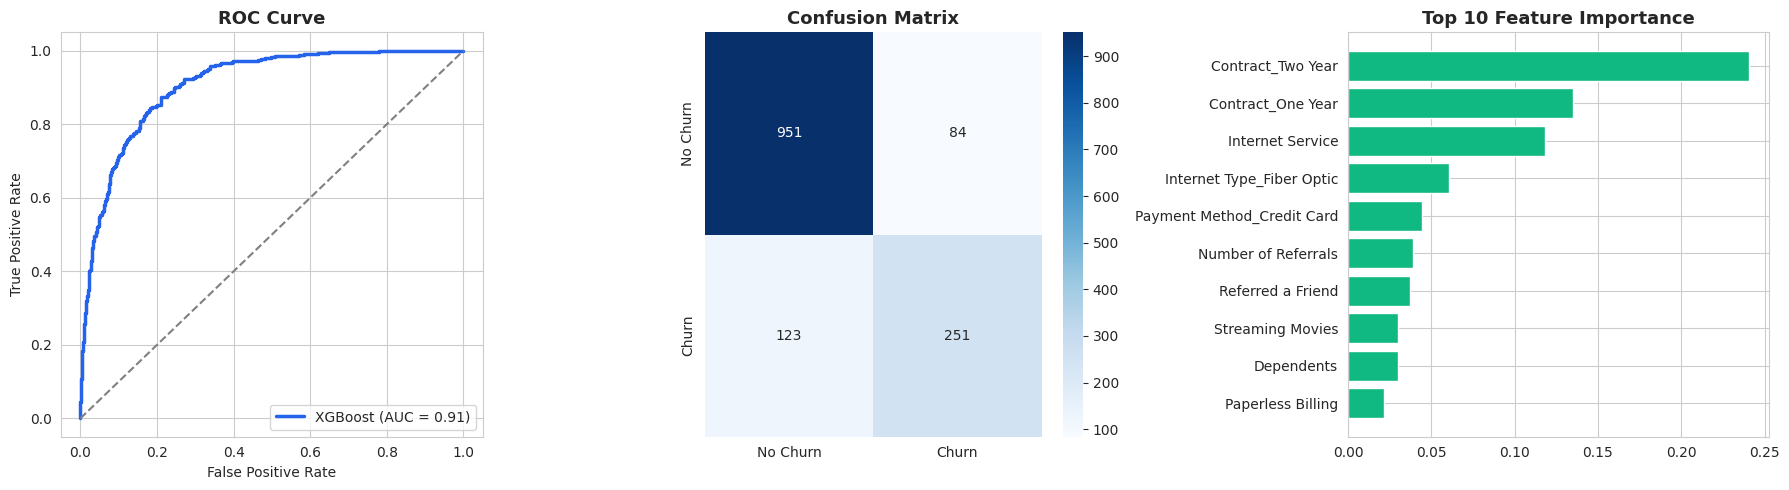

In [108]:
from sklearn.metrics import roc_curve, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, xgb_proba)
axes[0].plot(fpr, tpr, color='#2563eb', linewidth=2.5, label='XGBoost (AUC = 0.91)')
axes[0].plot([0,1],[0,1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[1].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
axes[2].barh(importance.index[::-1], importance.values[::-1], color='#10b981')
axes[2].set_title('Top 10 Feature Importance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [110]:
import joblib

# Apna Drive folder path (jahan CSV rakhi hai wahi ya naya folder bana lo)
save_path = '/content/drive/MyDrive/Data set/'

joblib.dump(xgb_model, save_path + 'telco_churn_model.pkl')
joblib.dump(X_train.columns.tolist(), save_path + 'model_columns.pkl')

print("Model saved to Google Drive successfully!")

Model saved to Google Drive successfully!
